# Day 5: Model Interpretability (SHAP)
Explaining global feature importance and individual predictions for the tuned XGBoost model.

In [4]:
import numpy as np 
import pandas as pd 
import joblib
import matplotlib.pyplot as plt 
from pathlib import Path
from sklearn.model_selection import train_test_split

DATA_PATH = Path("../data/processed/telco_churn_processed.csv")
df = pd.read_csv(DATA_PATH)

X = df.drop(columns = ["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

scaler = joblib.load("../outputs/models/scaler.joblib")
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "TotalServices"]
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

best_xgb = joblib.load("../outputs/models/xgboost_tuned.joblib")
print("Loaded tuned model. Test shape:", X_test.shape)

Loaded tuned model. Test shape: (1409, 27)


In [6]:
#using shap as it helps calculate how much each feature pushed the prediction up or down

import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape", shap_values.shape)

SHAP values shape (1409, 27)


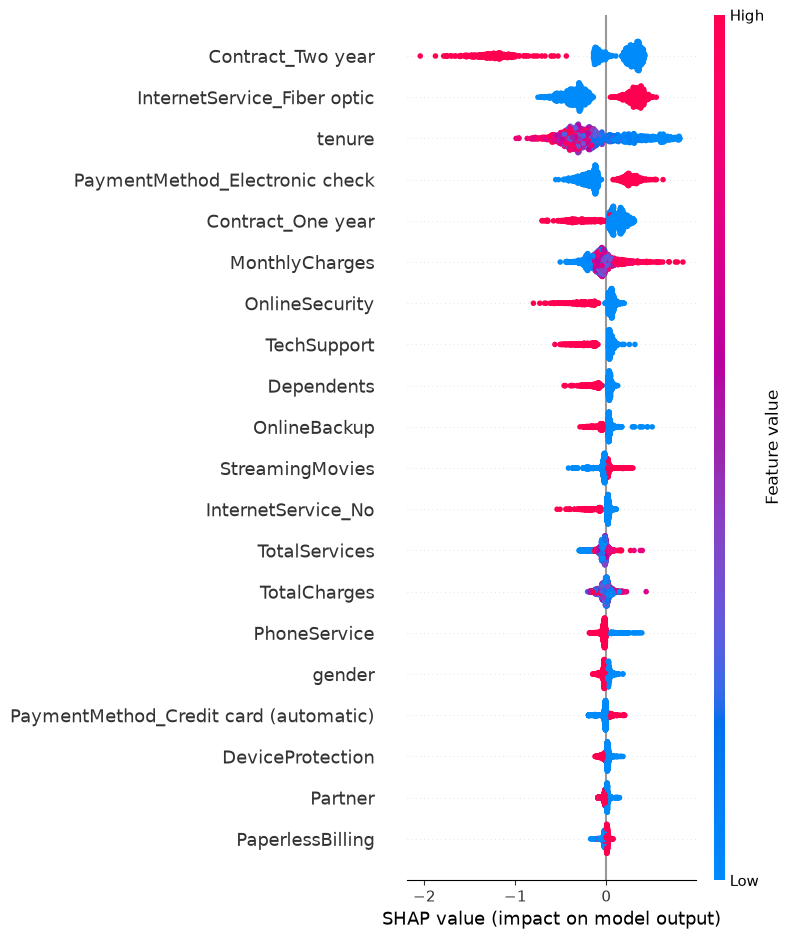

In [7]:
#Global featur importance - which feature matters the most and in which dPendingDeprecationWarning

shap.summary_plot(shap_values, X_test, show = False)
plt.tight_layout()
plt.savefig("../outputs/plots/shap_summary.png", dpi = 150, bbox_inches = "tight")
plt.show()

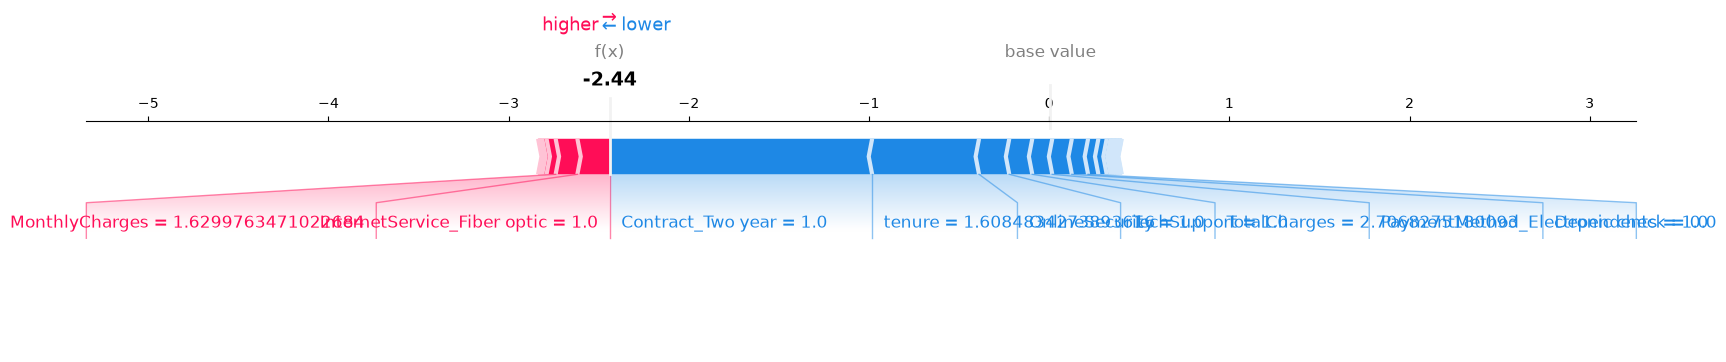

Predicted churn probability: 0.0802
Actual outcome: Did not churn


In [9]:
#local explaination - tells why model predicted what it predicted for that specific pRecursionError

customer_idx = 0 # picked any row index from X_test

shap.force_plot(explainer.expected_value, shap_values[customer_idx], X_test.iloc[customer_idx], matplotlib= True, show = False)

plt.savefig("../outputs/plots/shap_force_customer0.png", dpi = 150, bbox_inches = "tight")
plt.show()

print("Predicted churn probability:", round(best_xgb.predict_proba(X_test.iloc[[customer_idx]])[0][1],4))

print("Actual outcome:", "Churned" if y_test.iloc[customer_idx] == 1 else "Did not churn")